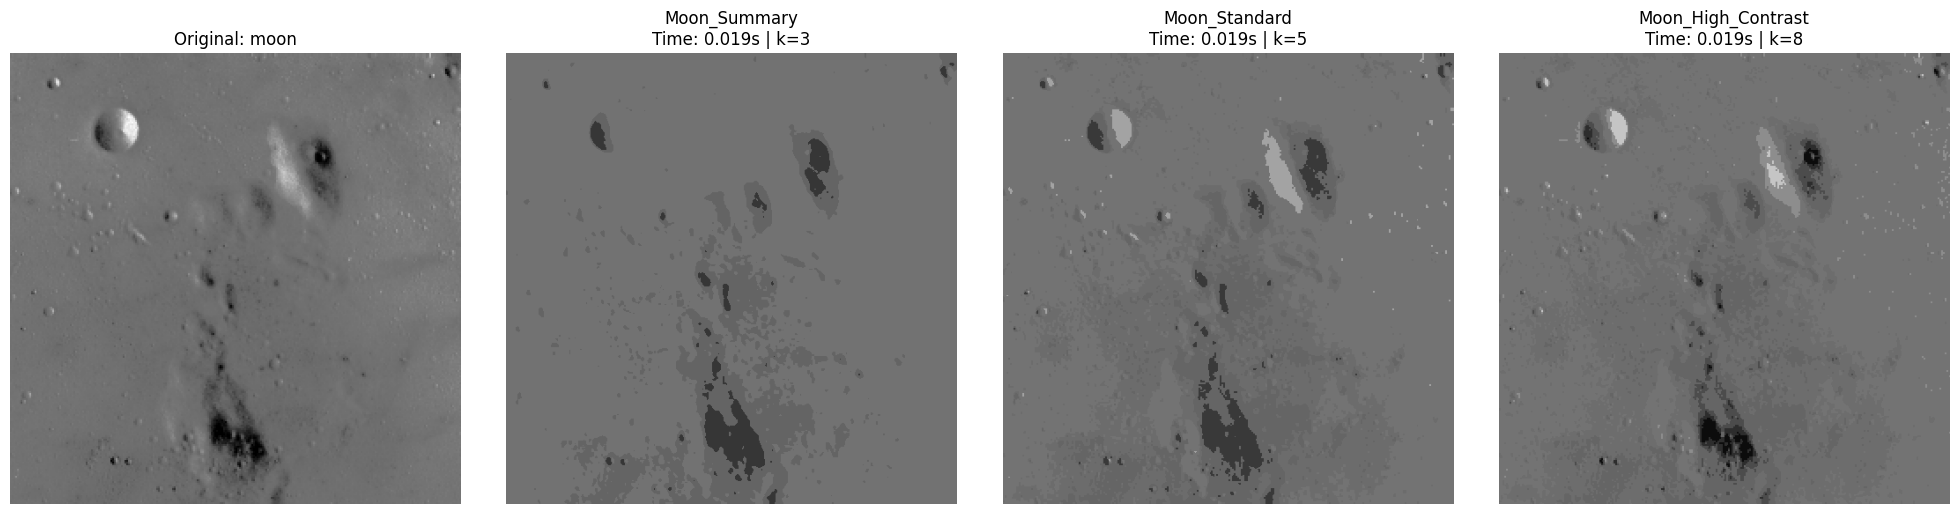

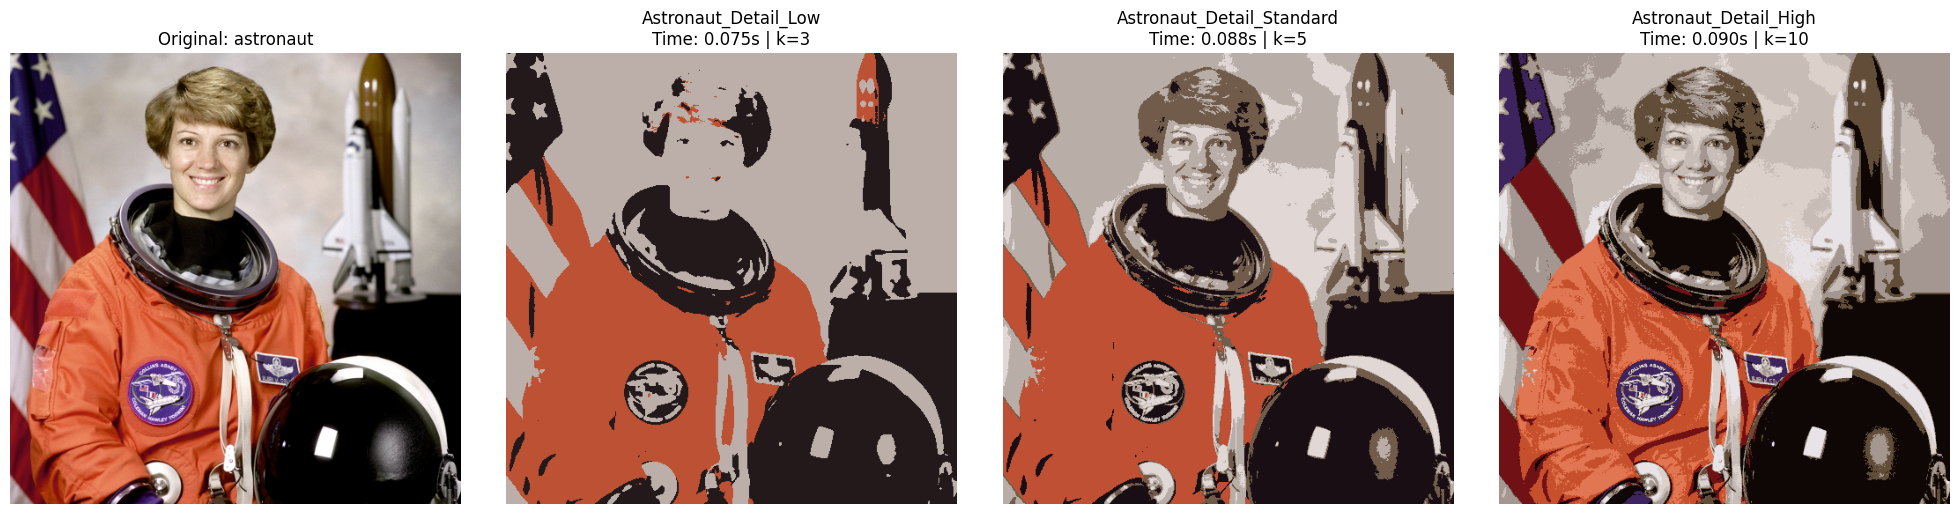

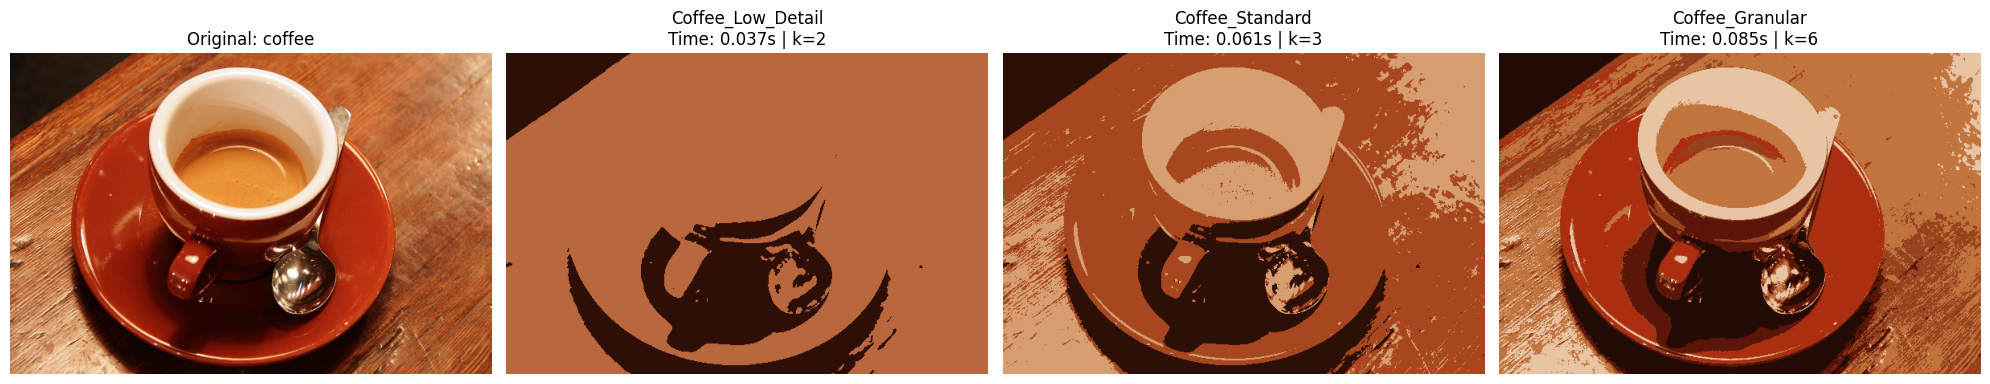

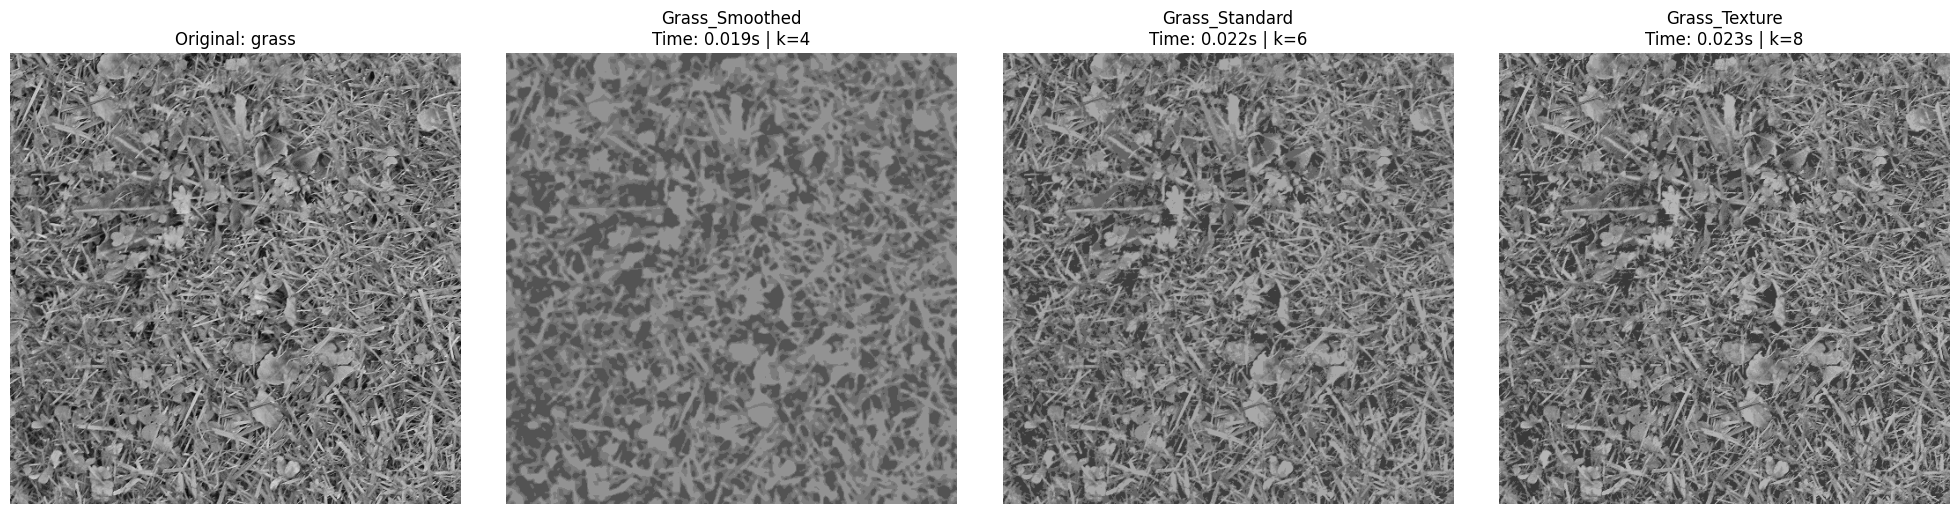

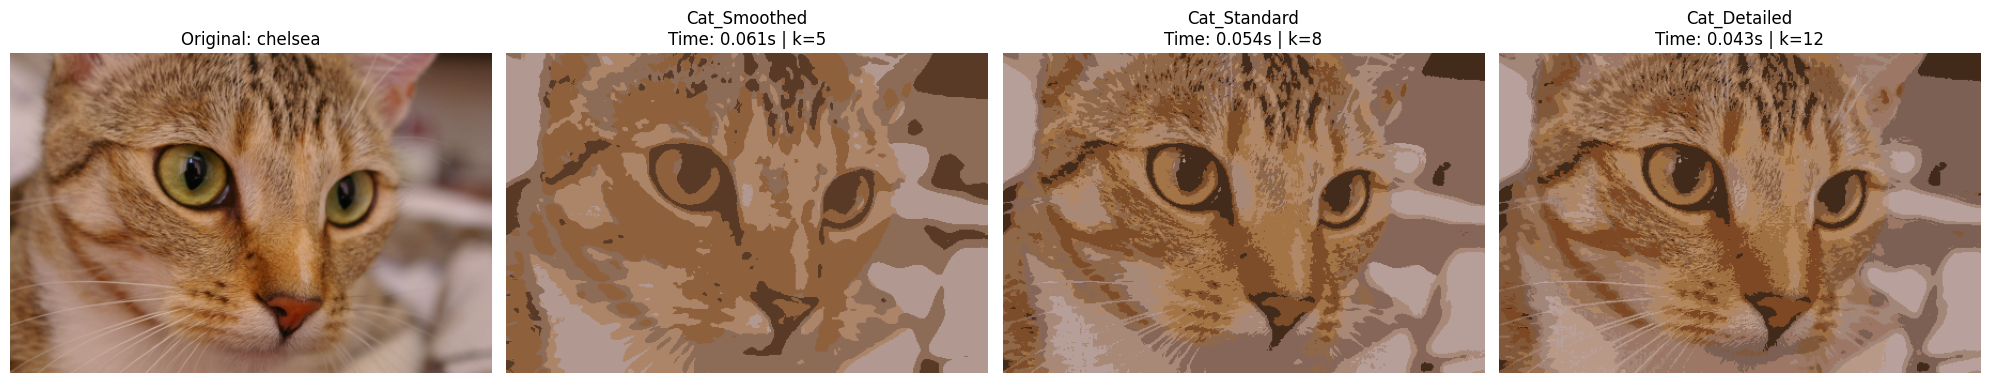

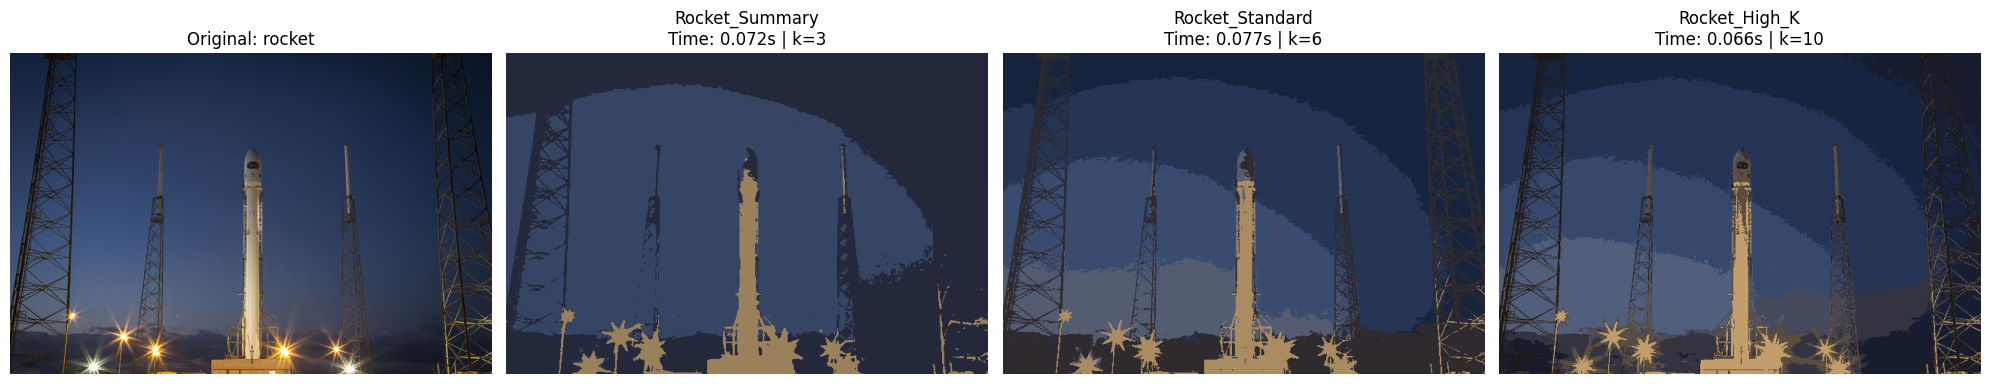

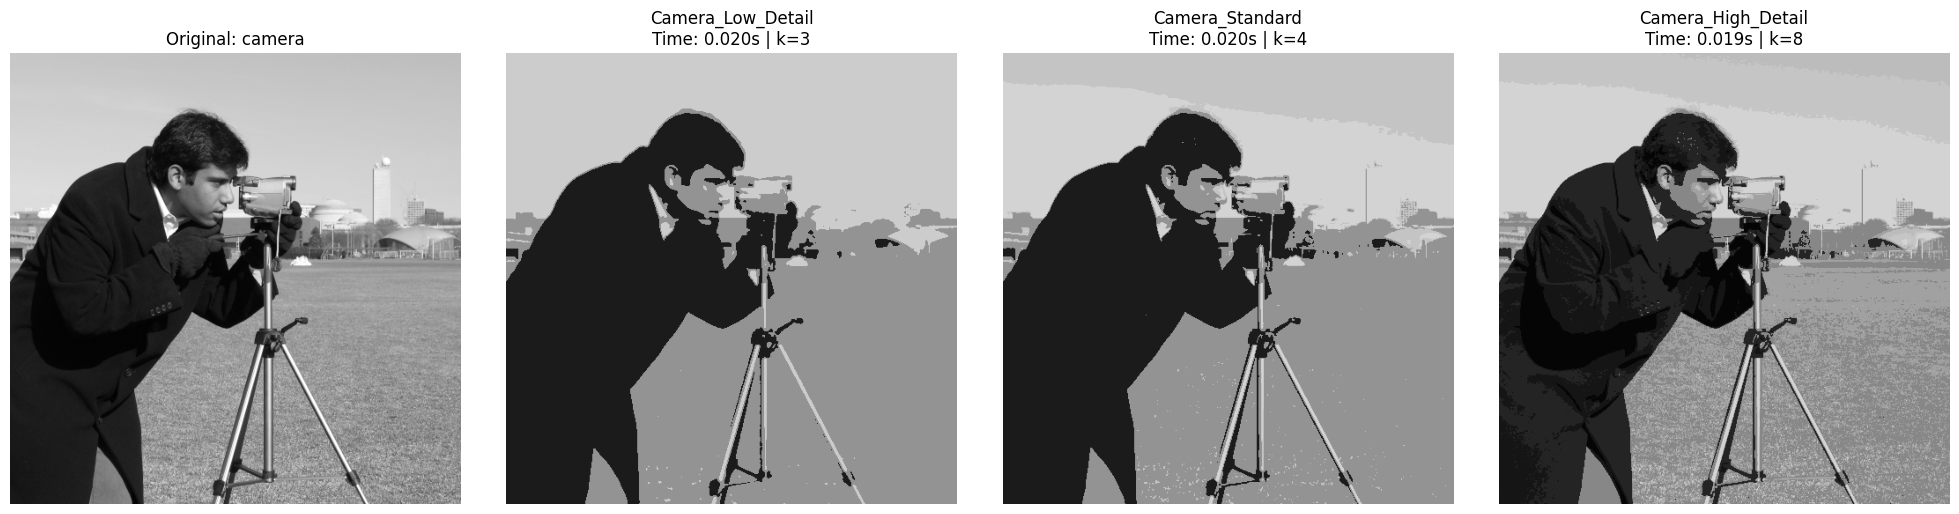

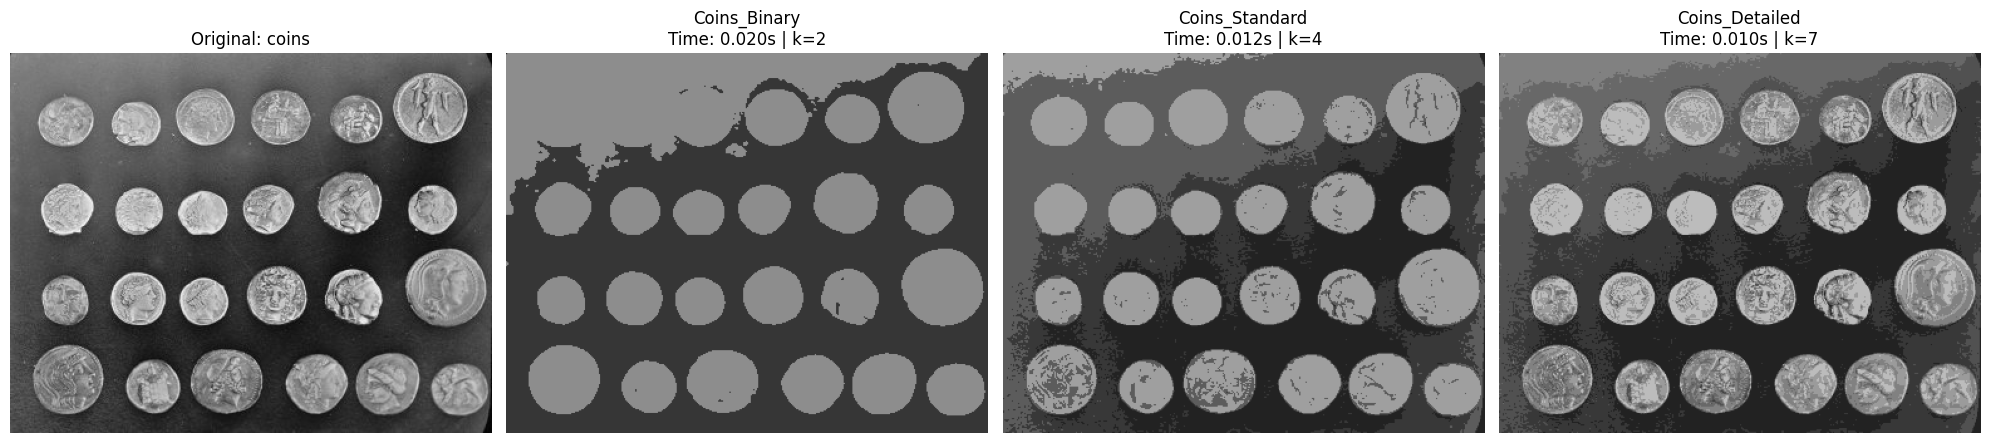

In [1]:
"""QBCA image segmentation analysis."""

import json
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage import color, data

from qbca import QBCA

# Load the comprehensive configuration
with open('config/config_segmentation.json', 'r') as f:
    config_data = json.load(f)

# Group experiments by image for a clear visual comparison
grouped = defaultdict(list)
for exp in config_data['experiments']:
    grouped[exp['image_func']].append(exp)

output_dir = Path('images/image_segmentation')
output_dir.mkdir(parents=True, exist_ok=True)

for img_func_name, exps in grouped.items():
    # Dynamic fetching from skimage.data
    img_func = getattr(data, img_func_name)
    img = img_func()

    # Handle Grayscale: Paper assumes 3-attribute points (L, a, b)
    if img.ndim == 2:
        img = color.gray2rgb(img)

    # Save source image for this family once
    plt.imsave(output_dir / f"{img_func_name}_original.png", img)

    n_cols = len(exps) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

    # Show Original
    axes[0].imshow(img)
    axes[0].set_title(f"Original: {img_func_name}")
    axes[0].axis('off')

    for idx, cfg in enumerate(exps):
        # Preprocessing: Gaussian smoothing
        img_smoothed = gaussian_filter(img, sigma=(cfg['sigma'], cfg['sigma'], 0))

        # Feature Extraction
        img_lab = color.rgb2lab(img_smoothed)
        pixel_data = img_lab.reshape((-1, 3))

        # QBCA Run with configuration from config
        model = QBCA(k=cfg['k'], threshold=cfg['epsilon'], max_iter=cfg['max_iter'])
        start_time = time.time()
        labels, centers, _ = model.fit(pixel_data)
        elapsed = time.time() - start_time

        # Reconstruction: Point assignment
        segmented_lab = centers[labels].reshape(img_lab.shape)
        segmented_rgb = color.lab2rgb(segmented_lab)

        # Plotting results
        ax = axes[idx + 1]
        ax.imshow(segmented_rgb)
        ax.set_title(f"{cfg['name']}\nTime: {elapsed:.3f}s | k={cfg['k']}")
        ax.axis('off')

        # Save each QBCA result with config-aligned naming
        plt.imsave(output_dir / f"{cfg['name']}_qbca.png", segmented_rgb)

    plt.tight_layout()

    # Save grouped comparison panel for this source image
    fig.savefig(output_dir / f"{img_func_name}_panel.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)